In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from umap import UMAP

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [2]:
df = pd.read_csv('00_authors.csv').rename(columns={'Unnamed: 0': 'Author'})
authors = df['Author'].values  # n_samples-length array
X = df.drop(columns=["BookID", "Author"]).values  
true_labels = pd.factorize(df["Author"])[0]
feature_names = df.drop(columns=["Author", "BookID"]).columns

# UMAP dimensionality reduction
umap_model = UMAP(n_neighbors=10, min_dist=0.3, random_state=42, n_jobs=1)
X_umap = umap_model.fit_transform(X)

In [ ]:
def poisson_mixture_em(X, K, max_iter=100, tol=1e-4, eps=1e-10, random_state=42):
    np.random.seed(random_state)
    X = np.asarray(X)
    N, d = X.shape

    # K-means initialization
    kmeans = KMeans(n_clusters=K, random_state=random_state).fit(X)
    w = np.bincount(kmeans.labels_) / N
    lam = np.vstack([X[kmeans.labels_ == k].mean(axis=0) for k in range(K)]) + eps
    
    for _ in range(max_iter):
        # E-step (log-space)
        log_pi = np.zeros((N, K))
        for k in range(K):
            log_pi[:, k] = (
                np.log(w[k] + eps) +
                (X * np.log(lam[k] + eps)).sum(axis=1) -
                lam[k].sum()
            )

        # log-sum-exp for numeric stability
        m = log_pi.max(axis=1, keepdims=True)
        pi = np.exp(log_pi - m)
        pi /= pi.sum(axis=1, keepdims=True)

        # M-step
        Nk = pi.sum(axis=0) + eps
        w_new = Nk / N
        
        lam_new = (pi.T @ X) / Nk[:, None]

        # convergence check
        if np.max(np.abs(lam_new - lam)) < tol:
            break

        lam = lam_new
        w = w_new

    return w, lam, pi

In [4]:
K = 4
w, lam, pi = poisson_mixture_em(X, K)

poisson_labels = pi.argmax(axis=1)
poisson_certainty = pi.max(axis=1)

In [5]:
gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)
gmm_certainty = gmm_probs.max(axis=1)

In [6]:
print("Poisson ARI:", adjusted_rand_score(true_labels, poisson_labels))
print("Gaussian ARI:", adjusted_rand_score(true_labels, gmm_labels))

Poisson ARI: 0.9233262435084179
Gaussian ARI: 0.747897482717644


In [7]:
def top_words_per_cluster(lam, words, top_n=8):
    for k in range(lam.shape[0]):
        idx = np.argsort(lam[k])[::-1][:top_n]
        print(f"\nCluster {k} top words:")
        for w in idx:
            print(f"{words[w]} (λ={lam[k][w]:.2f})")
            
top_words_per_cluster(lam, feature_names)


Cluster 0 top words:
the (λ=61.45)
to (λ=55.58)
and (λ=51.87)
of (λ=49.08)
a (λ=31.28)
her (λ=30.34)
was (λ=25.74)
in. (λ=25.49)

Cluster 1 top words:
the (λ=111.11)
and (λ=63.07)
of (λ=50.47)
to (λ=37.79)
a (λ=35.23)
was (λ=34.24)
in. (λ=29.25)
it (λ=21.03)

Cluster 2 top words:
the (λ=57.92)
and (λ=52.23)
of (λ=36.26)
to (λ=35.33)
a (λ=28.01)
my (λ=22.61)
in. (λ=21.41)
that (λ=20.82)

Cluster 3 top words:
and (λ=72.89)
the (λ=62.78)
to (λ=48.02)
of (λ=44.18)
in. (λ=28.71)
his (λ=24.47)
with (λ=23.75)
or (λ=15.85)


In [8]:
threshold = 0.95
uncertain_idx = np.where(poisson_certainty < threshold)[0]

print("Low-certainty chapters (Poisson):", uncertain_idx)
print("Count:", len(uncertain_idx))


Low-certainty chapters (Poisson): [ 32 332 333 385 413 519 526 767]
Count: 8


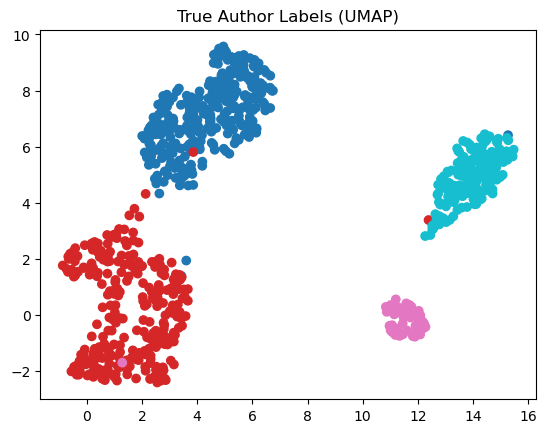

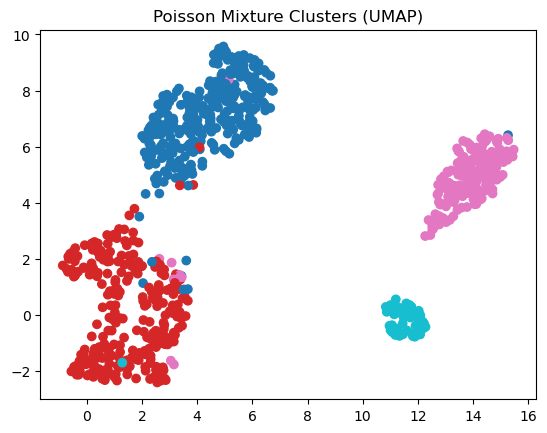

In [9]:
# True authors
plt.scatter(X_umap[:,0], X_umap[:,1], c=true_labels, cmap='tab10')
plt.title("True Author Labels (UMAP)")
plt.show()

# Poisson clusters
plt.scatter(X_umap[:,0], X_umap[:,1], c=poisson_labels, cmap='tab10')
plt.title("Poisson Mixture Clusters (UMAP)")
plt.show()


In [10]:
print("w:", w)
print("lam min/max:", lam.min(), lam.max())
print("pi row sums:", pi.sum(axis=1)[:10])
print("any nan?", np.isnan(lam).any(), np.isnan(pi).any())


w: [0.38191055 0.33425017 0.21844094 0.06539834]
lam min/max: 0.01818181638698571 111.10507378301017
pi row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
any nan? False False
